### Installations


In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    %pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
# Install transformers branch for Ministral
!pip install git+https://github.com/huggingface/transformers.git@bf3f0ae70d0e902efab4b8517fce88f6697636ce
!pip install --no-deps trl==0.22.2

In [2]:
%pip install backtrader
%pip install alpaca_trade_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 19.8 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.3-cp312-cp312-linux_x86_64.whl size=15688 sha256=76bdb4ef329994cbc2555e1dbe623e1443ca1b149596a8d40eccc89b17bed6de
  Stored in directory: /root/.cache/pip/wheels/ba/bd/3f/f043e8f634db9c90ae128d631f43ae9990eef01274a63291f9
  Created wheel for websockets: filename=websockets-10.4-cp312-cp312-linux_x86_64.whl size=107331 sha256=fe00a173fa73a6b729904bc15ad118e1e1ac3173694cde199590dc451

### Unsloth


In [10]:
import torch
from unsloth import FastVisionModel
from transformers import TextStreamer
from trl import GRPOConfig, GRPOTrainer

class Unsloth:
    
    def __init__(self, model_name: str, lora_rank: int = 32, max_seq_length: int = 4096, load_in_4bit = True, fast_inference = False, max_prompt_length = 512):
        self.model_name = model_name
        self.lora_rank = lora_rank 
        self.max_seq_length = max_seq_length
        self.max_prompt_length = max_prompt_length
        self.load_in_4bit = load_in_4bit
        self.fast_inference = fast_inference
        
        self.model, self.tokenizer = FastVisionModel.from_pretrained(
            model_name = self.model_name,
            max_seq_length = self.max_seq_length,
            load_in_4bit = self.load_in_4bit, # True for QLora
            fast_inference = self.fast_inference, # Enable vLLM fast inference, only for inference
        )

        self.model = FastVisionModel.get_peft_model(
            self.model,
            r = self.lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
            target_modules = [
                "q_proj", "k_proj", "v_proj", "o_proj",
                "gate_proj", "up_proj", "down_proj",
            ],
            lora_alpha = self.lora_rank*2, # *2 speeds up training
            use_gradient_checkpointing = "unsloth", # Reduces memory usage
            random_state = 3407,
        )
        
    
    def generate(self, inputs: str):
        text = self.tokenizer.apply_chat_template(
            [{"role": "user", "content": inputs.strip()}],
            tokenize = False,
            add_generation_prompt = True,
        )
        
        output = self.model.generate(
            **self.tokenizer(images=None,text=text, return_tensors = "pt").to("cuda"),
            temperature = 1.0,
            max_new_tokens = self.max_seq_length - self.max_prompt_length,
            streamer = TextStreamer(self.tokenizer, skip_prompt = True),
        )
        
        return self.tokenizer.decode(output[0], skip_special_tokens=True)
    
    def train(self, steps: int, reward_functions: list, dataset: torch.utils.data.Dataset):
        max_prompt_length = self.max_prompt_length + 1 # + 1 just in case!
        max_completion_length = self.max_seq_length - max_prompt_length

        training_args = GRPOConfig(
            temperature = 1.0,
            learning_rate = 5e-6,
            weight_decay = 0.01,
            warmup_ratio = 0.1,
            lr_scheduler_type = "linear",
            optim = "adamw_8bit",
            logging_steps = 1,
            per_device_train_batch_size = 2,
            gradient_accumulation_steps = 8, # Increase to 4 for smoother training
            num_generations = 2, # Decrease if out of memory
            max_prompt_length = max_prompt_length,
            max_completion_length = max_completion_length,
            # num_train_epochs = 1, # Set to 1 for a full training run
            max_steps = steps,
            save_steps = steps,
            report_to = "none", # Can use Weights & Biases, TrackIO
            output_dir = "outputs",
        )

        trainer = GRPOTrainer(
            model = self.model,
            processing_class = self.tokenizer,
            reward_funcs = reward_functions,
            args = training_args,
            train_dataset = dataset,

            # For optional training + evaluation
            # train_dataset = new_dataset["train"],
            # eval_dataset = new_dataset["test"],
        )
        
        trainer.train()


### Backtest Implementation


In [4]:
import backtrader as bt
import matplotlib as mpl
import matplotlib.pyplot as plt
from alpaca_trade_api.rest import REST, TimeFrame
from unsloth import execute_with_time_limit
from IPython.display import Image, display

class Backtrader:
    _data_cache = {}  # shared across all instances, persists for the training run

    def __init__(self):
        # Load API Key ID and Secret Key from Colab secrets
        self.api_key = "PKYFWRKKNCNJMVFLZD4OYLREDU"
        self.api_secret_key = "Yh5L9VeVsWPuShX6aUfuZGshyJ8o2RdresyrB9pe5hx"
        self.base_url = "https://paper-api.alpaca.markets"
        self.rest_api = REST(self.api_key, self.api_secret_key, self.base_url)

    def _get_bars(self, symbol, timeframe, start, end):
        key = (symbol, str(timeframe), start, end)
        if key not in Backtrader._data_cache:
            Backtrader._data_cache[key] = self.rest_api.get_bars(symbol, timeframe, start, end, adjustment='all').df
        return Backtrader._data_cache[key]

    def load_bars(self, symbols=None, start=None, end=None, timeframe=TimeFrame.Day):
        """Pre-fetch and cache bar data for all symbols before training."""
        symbols = symbols or Data.SYMBOLS
        start   = start   or Data.START
        end     = end     or Data.END

        print(f"Pre-fetching bar data for {len(symbols)} symbols ({start} → {end})...")
        for i, symbol in enumerate(symbols, 1):
            self._get_bars(symbol, timeframe, start, end)
            print(f"  [{i}/{len(symbols)}] {symbol} ✓")
        print(f"Done. {len(Backtrader._data_cache)} entries cached.")

    def run_backtest(self, strategy, symbols, start, end, timeframe=TimeFrame.Day, cash=10000):
        '''params:
            strategy: the strategy you wish to backtest, an instance of backtrader.Strategy
            symbols: the symbol (str) or list of symbols List[str] you wish to backtest on
            start: start date of backtest in format 'YYYY-MM-DD'
            end: end date of backtest in format: 'YYYY-MM-DD'
            timeframe: the timeframe the strategy trades on (size of bars) -
                    1 min: TimeFrame.Minute, 1 day: TimeFrame.Day, 5 min: TimeFrame(5, TimeFrameUnit.Minute)
            cash: the starting cash of backtest
        returns: (return_pct, sharpe_ratio, avg_annual_return_pct, max_drawdown_pct)
        '''

        # initialize backtrader broker
        cerebro = bt.Cerebro(stdstats=True)
        cerebro.broker.setcash(cash)

        # add strategy
        cerebro.addstrategy(strategy)
        cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='mysharpe')
        cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name='annual_return')
        cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

        # historical data request (cached)
        if type(symbols) == str:
            alpaca_data = self._get_bars(symbols, timeframe, start, end)
            cerebro.adddata(bt.feeds.PandasData(dataname=alpaca_data, name=symbols))
        elif type(symbols) == list or type(symbols) == set:
            for symbol in symbols:
                alpaca_data = self._get_bars(symbol, timeframe, start, end)
                cerebro.adddata(bt.feeds.PandasData(dataname=alpaca_data, name=symbol))

        # run
        initial_portfolio_value = cerebro.broker.getvalue()
        results = cerebro.run()
        final_portfolio_value = cerebro.broker.getvalue()
        _return = (final_portfolio_value/initial_portfolio_value - 1)*100

        strat = results[0]
        sharpe_ratio = strat.analyzers.mysharpe.get_analysis()['sharperatio']
        annual_returns = strat.analyzers.annual_return.get_analysis()  # {year: decimal}
        avg_annual_return = (sum(annual_returns.values()) / len(annual_returns) * 100) if annual_returns else 0.0
        max_drawdown = strat.analyzers.drawdown.get_analysis()['max']['drawdown']

        print(f"Return:             {_return:.2f}%")
        print(f"Sharpe Ratio:       {sharpe_ratio}")
        print(f"Avg Annual Return:  {avg_annual_return:.2f}%")
        print(f"Max Drawdown:       {max_drawdown:.2f}%")

        if _return != 0 and sharpe_ratio is not None:
            cerebro.plot(iplot=False)  # creates matplotlib figures when using Agg
            for i, fig_num in enumerate(plt.get_fignums(), start=1):
                plt.figure(fig_num)
                filename = f'backtest_plot_{i}.png'
                plt.savefig(filename, dpi=140, bbox_inches='tight')
                display(Image(filename))
            plt.close('all')

        return _return, sharpe_ratio, avg_annual_return, max_drawdown

    @execute_with_time_limit(10)
    def execute_strategy(self, strategy, symbols, start, end, timeframe=TimeFrame.Day, cash=10000):
        """Execute strategy with 10 second time limit."""
        return self.run_backtest(strategy, symbols, start, end, timeframe, cash)


### Data Preparation


In [5]:
from datasets import Dataset

class Data:
    SYMBOLS = [
        'AAPL', 'AMGN', 'AXP', 'BA',  'CAT',
        'CRM',  'CSCO', 'CVX', 'DIS', 'DOW',
        'GS',   'HD',   'HON', 'IBM', 'JNJ',
        'JPM',  'KO',   'MCD', 'MMM', 'MRK',
        'MSFT', 'NKE',  'NVDA','PG',  'TRV',
        'UNH',  'V',    'VZ',  'WBA', 'WMT',
    ]
    START = '2016-01-01'
    END   = '2024-12-31'

    def __init__(self):
        records = []
        for symbol in self.SYMBOLS:
            prompt = self._make_prompt(symbol)
            records.append({
                "prompt": [{"role": "user", "content": prompt}],
                "answer": 0,
            })
        self.dataset = Dataset.from_list(records)

    def _make_prompt(self, symbol: str) -> str:
        return f"""
        Create a trading strategy for {symbol} from {self.START} to {self.END} that is fully compatible with the following backtesting setup:

        - Framework: Backtrader
        - Strategy must subclass bt.Strategy
        - The strategy will be passed directly into:
        run_backtest(StrategyClass, symbols, start, end, timeframe, cash)

        STRICT RULES:
        1. Output ONLY a single Python class definition (no explanations, no markdown, no comments outside the class).
        2. The class MUST be named Strategy.
        3. Do NOT include imports (bt is already available).
        4. Do NOT reference external data, files, APIs, or indicators outside Backtrader.
        5. The strategy MUST work for Single-symbol strategies.
        6. All indicators must be created in __init__.
        7. Trading logic must be implemented in next().
        8. Orders must use only:
        - self.buy()
        - self.sell()
        - self.close()
        - self.order_target_percent()
        9. No plotting, printing, logging, or analyzers.
        10. Strategy must be deterministic and backtest-safe (no lookahead bias).

        OUTPUT FORMAT:
        Return ONLY the Python class exactly like this structure:

        class Strategy(bt.Strategy):

            params = dict(
                # parameters here
            )

            def __init__(self):
                # indicator definitions

            def next(self):
                # trading logic

        DO NOT output anything else.
        """.strip()

    def get_dataset(self):
        return self.dataset


### Reward Function


In [ ]:
import re
import os
import shutil
import json
from datetime import datetime
from unsloth import check_python_modules

class RewardFunctions:
    
    RED = "\033[91m"
    RESET = "\033[0m"

    def extract_function(text):
        """Extract Python function from markdown code blocks."""
        if text.count("```") >= 2:
            first = text.find("```") + 3
            second = text.find("```", first)
            fx = text[first:second].strip()
            fx = fx.removeprefix("python\n")
            fx = fx[fx.find("class Strategy"):]
            if fx.startswith("class Strategy(bt.Strategy):"):
                return fx
        else:
            fx = text.strip()
            fx = fx[fx.find("class Strategy"):]
            if fx.startswith("class Strategy(bt.Strategy):"):
                return fx
        return None

    def function_works(function):
        """Checks if the generated code is valid Python and can be executed."""
        if function is not None:
            ok, info = check_python_modules(function)

        if function is None or ok is False or "error" in info:
            return False
        
        return True 

    def extract_trading_parameters(prompt):
        """Extract symbol, start, and end date from the embedded prompt text."""
        match = re.search(r'trading strategy for (\w+) from (\S+) to (\S+)', prompt)
        if match:
            return match.group(1), match.group(2), match.group(3)
        raise ValueError(f"Could not extract trading parameters from prompt: {prompt[:100]}")

    def extract_strategy(func):
        namespace = {'bt': bt}
        exec(func, namespace)
        return namespace['Strategy']

    def has_required_functions(text):
        has_init = bool(re.search(r'def\s+__init__\s*\([^)]*\)\s*:', text))
        has_next = bool(re.search(r'def\s+next\s*\([^)]*\)\s*:', text))
        return has_init and has_next

    def save_strategy(function, _return, sharpe_ratio, avg_annual_return, max_drawdown, symbol, start, end):
        """Save a successful strategy with its stats and plots to a timestamped folder."""
        save_dir = "successful_strategies"
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        strategy_dir = os.path.join(save_dir, f"{timestamp}_{symbol}")
        os.makedirs(strategy_dir, exist_ok=True)

        with open(os.path.join(strategy_dir, "strategy.py"), "w") as f:
            f.write(function)

        stats = {
            "symbol": symbol,
            "start": start,
            "end": end,
            "return_pct": round(_return, 4),
            "sharpe_ratio": round(sharpe_ratio, 4) if sharpe_ratio is not None else None,
            "avg_annual_return_pct": round(avg_annual_return, 4),
            "max_drawdown_pct": round(max_drawdown, 4),
        }
        with open(os.path.join(strategy_dir, "stats.json"), "w") as f:
            json.dump(stats, f, indent=2)

        for i in range(1, 10):
            src = f"backtest_plot_{i}.png"
            if os.path.exists(src):
                shutil.copy(src, os.path.join(strategy_dir, f"plot_{i}.png"))

        print(f"Saved to {strategy_dir}/")

    # (doesn't try, -10)->(invalid code, -3)->(exception, -2)->(no trading, -1)->(negative return, 0)->(positive return, return)
    def strategy_succeeds(completions, prompts, **kwargs):
        """Reward valid moves even if strategy eventually fails."""
        scores = []
        backtrader = Backtrader()

        # extract trading parameters from the prompt (all completions share the same prompt)
        prompt_text = prompts[0][-1]["content"]
        symbol, start, end = RewardFunctions.extract_trading_parameters(prompt_text)
        print("="*50)
        print(f"{symbol}--{start}--{end}")

        for completion in completions:
            response = completion[0]["content"]
            function = RewardFunctions.extract_function(response)

            if not RewardFunctions.function_works(function):
                scores.append(-3)
                continue

            if not RewardFunctions.has_required_functions(function):
                scores.append(-10)
                continue

            try:
                strategy = RewardFunctions.extract_strategy(function)
                _return, sharpe_ratio, avg_annual_return, max_drawdown = backtrader.execute_strategy(strategy, symbols=symbol, start=start, end=end, timeframe=TimeFrame.Day, cash=10000)

                if _return == 0 and sharpe_ratio is None:
                    scores.append(-1)
                    continue

                if _return > 0:
                    print(function)
                    # RewardFunctions.save_strategy(function, _return, sharpe_ratio, avg_annual_return, max_drawdown, symbol, start, end)

                scores.append(max(avg_annual_return, 0))

            except TimeoutError:
                print("Timeout")
                scores.append(-2.0)
            except Exception as e:
                print(f"{RewardFunctions.RED}Exception: {str(e)[:100]}{RewardFunctions.RESET}")
                scores.append(-2.0)

        return scores


### Main


In [26]:
model = Unsloth(model_name = "unsloth/meta-Llama-3.1-8B-Instruct", max_seq_length=1024)

==((====))==  Unsloth 2026.3.4: Fast Llama patching. Transformers: 5.0.0.dev0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Making `model.base_model.model.model` require gradients


In [15]:
data = Data()
sample_prompt = data.dataset[0]["prompt"]
func = model.generate(sample_prompt[-1]["content"])
scores = RewardFunctions.strategy_succeeds([[{"content": func}]], prompts=[sample_prompt])
print(scores)

class Strategy(bt.Strategy):

    params = dict(
        period1=20, 
        period2=50, 
        period3=10, 
        threshold=0.01
    )

    def __init__(self):
        self.bollinger_fast = bt.indicators.BBands(period=self.p.period1, nbdevup=2, nbdevdn=2, movingavg=self.p.period1)
        self.bollinger_medium = bt.indicators.BBands(period=self.p.period2, nbdevup=2, nbdevdn=2, movingavg=self.p.period2)
        self.bollinger_slow = bt.indicators.BBands(period=self.p.period3, nbdevup=2, nbdevdn=2, movingavg=self.p.period3)
        self.rsi = bt.indicators.RSI(period=self.p.period1)

    def next(self):
        if not self.position:
            if self.bollinger_fast.bot[0] < self.data.close[0] and self.rsi < 30:
                self.buy(exectype=bt.Order.Market, size=100)
            elif self.bollinger_medium.bot[0] > self.data.close[0] and self.rsi > 70:
                self.sell(exectype=bt.Order.Market, size=100)
        else:
            if self.data.close[0] < self.data.clos

In [27]:
sample = data.dataset[0]["prompt"]                                                                                                                    
text = model.tokenizer.apply_chat_template(sample, tokenize=False, add_generation_prompt=True)
                                                                                                                                                        
# prompt tokens 
prompt_tokens = model.tokenizer(text, return_tensors="pt")["input_ids"].shape[1]
print(f"Prompt tokens: {prompt_tokens}")

# generate and check completion tokens
output = model.model.generate(
        **model.tokenizer(images=None,text=text, return_tensors = "pt").to("cuda"),
        temperature = 1.0,
        max_new_tokens = model.max_seq_length - model.max_prompt_length,
        streamer = TextStreamer(model.tokenizer, skip_prompt = True),
    )
completion_tokens = output.shape[1] - prompt_tokens
print(f"Completion tokens: {completion_tokens}")
print(f"Total tokens: {output.shape[1]}")

Prompt tokens: 355
class Strategy(bt.Strategy):

    params = dict(
        period1=20, 
        period2=50, 
        period3=10, 
        threshold=0.01
    )

    def __init__(self):
        self.bollinger_fast = bt.indicators.BBands(period=self.p.period1, nbdevup=2, nbdevdn=2, movingavg=self.p.period1)
        self.bollinger_medium = bt.indicators.BBands(period=self.p.period2, nbdevup=2, nbdevdn=2, movingavg=self.p.period2)
        self.bollinger_slow = bt.indicators.BBands(period=self.p.period3, nbdevup=2, nbdevdn=2, movingavg=self.p.period3)
        self.rsi = bt.indicators.RSI(period=self.p.period1)

    def next(self):
        if not self.position:
            if self.bollinger_fast.bot[0] < self.data.close[0] and self.rsi < 30:
                self.buy(exectype=bt.Order.Market, size=100)
            elif self.bollinger_medium.bot[0] > self.data.close[0] and self.rsi > 70:
                self.sell(exectype=bt.Order.Market, size=100)
        else:
            if self.data.close[

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 30 | Num Epochs = 34 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 83,886,080 of 8,114,147,328 (1.03% trained)


Unsloth: Will smartly offload gradients to save VRAM!
MRK--2016-01-01--2024-12-31
Exception: AttributeError: 'LineBuffer' object has no attribute 'plotinfo'
Remote traceback:
Traceback (most re
Return:             0.00%
Sharpe Ratio:       None
Avg Annual Return:  0.00%
Max Drawdown:       0.00%
Exception: TypeError: MovingAverageSimple.__init__() got an unexpected keyword argument 'name'
Remote traceback
Exception: NameError: name 'selfRSI' is not defined
Remote traceback:
Traceback (most recent call last):
  File
Return:             0.00%
Sharpe Ratio:       None
Avg Annual Return:  0.00%
Max Drawdown:       0.00%
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / strategy_succeeds / mean,rewards / strategy_succeeds / std
1,0.000009,-2.500000,0.530330,278.000000,150.000000,511.000000,0.125000,244.714294,150.000000,398.000000,0.009098,-2.500000,0.730297
2,0.000007,-2.625000,0.530330,290.687500,122.000000,511.000000,0.125000,259.214294,122.000000,388.000000,0.007104,-2.625000,0.500000
3,0.000013,-2.302219,0.633258,302.437500,172.000000,511.000000,0.062500,288.533356,172.000000,413.000000,0.013434,-2.302219,0.902725
4,0.000017,-2.498413,0.709351,296.500000,165.000000,511.000000,0.125000,265.857147,165.000000,385.000000,0.016657,-2.498413,0.899168
5,0.000029,-2.186675,0.619886,254.312500,184.000000,443.000000,0.000000,254.312500,184.000000,443.000000,0.029495,-2.186675,0.983038
6,0.000109,-2.375000,0.530330,282.625000,145.000000,511.000000,0.125000,250.000015,145.000000,402.000000,0.108700,-2.375000,0.885061
7,0.000194,-2.556282,0.450735,248.312500,112.000000,511.000000,0.000000,248.312500,112.000000,511.000000,0.193517,-2.556282,0.834931
8,0.000239,-2.185034,0.975759,276.375000,175.000000,511.000000,0.062500,260.733337,175.000000,460.000000,0.239400,-2.185034,1.052349
9,0.000251,-2.562500,0.088388,306.812500,171.000000,499.000000,0.000000,306.812500,171.000000,499.000000,0.250772,-2.562500,0.512348
10,0.000472,-2.375000,0.353553,295.187500,156.000000,511.000000,0.125000,264.357147,156.000000,398.000000,0.471542,-2.375000,0.500000


WBA--2016-01-01--2024-12-31
Exception: AttributeError: module 'backtrader' has no attribute 'indgetVar'
Remote traceback:
Traceback (most r
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Exception: AttributeError: 'AutoInfoClass_LineRoot_LineMultiple_LineSeries_LineIterator_DataAccessor_StrategyBa
Exception: TypeError: MovingAverageSimple.__init__() got an unexpected keyword argument 'close'
Remote tracebac
Exception: TypeError: MACD.__init__() got an unexpected keyword argument 'fastperiod'
Remote traceback:
Traceba
TRV--2016-01-01--2024-12-31
Exception: AttributeError: module 'backtrader.indicators' has no attribute 'StatisticalMoment'
Remote traceback
Exception: AttributeError: module 'backtrader.indicators' has no attribute 'dllharmathmacd'
Remote traceback:
T
Exception: AttributeError: 'Lines_LineSeries_Lin

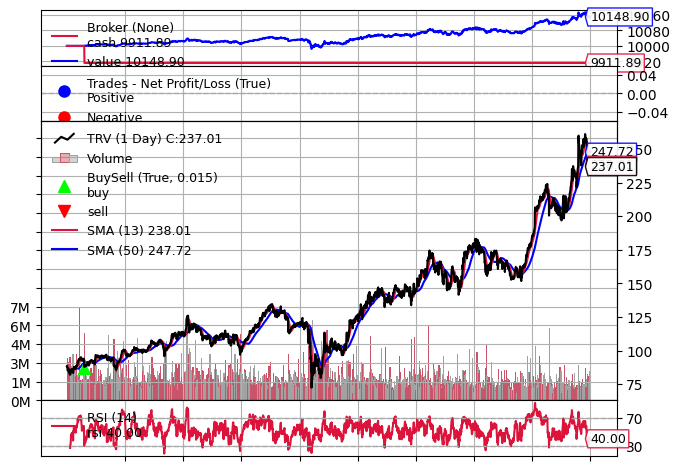

class Strategy(bt.Strategy):

    params = dict(
        fast_window=13,
        slow_window=50,
        rsi_window=14,
        sma_fast_mul=3,
        sma_short_mul=2,
        percentage=float(0.7),
        target_multiplier=float(5)
    )

    def __init__(self):
        self.data.close.plotinfo = dict(
            subtitle='Close',
            alinesparams=dict(
                linewidth=1,
                color='r',
                linestyle='--'
            )
        )
        self.sma_fast = bt.ind.SMA(period=self.params.fast_window)
        self.sma_slow = bt.ind.SMA(period=self.params.slow_window)
        self.rsi = bt.ind.RSI(period=self.params.rsi_window)

    def next(self):
        if not self.position:
            if self.sma_fast > self.sma_slow and self.rsi < 30:
                self.buy(exectype=bt.Order.Market)
            elif self.sma_fast < self.sma_slow and self.rsi > 70:
                self.sell(exectype=bt.Order.Market)
        else:
            if self.rsi > se

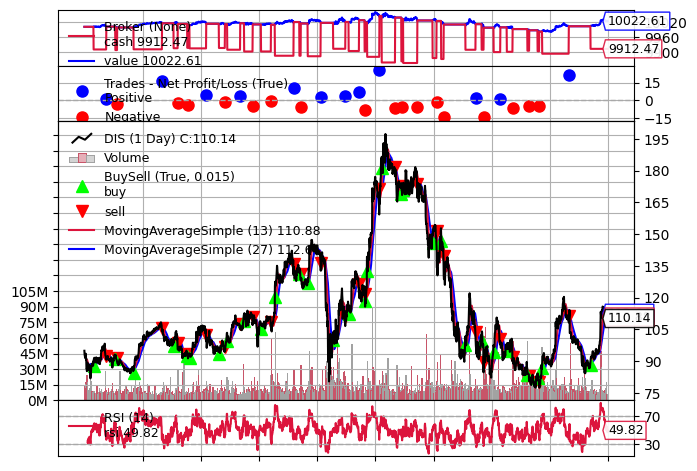

class Strategy(bt.Strategy):

    params = dict(
        fast=13,
        slow=27,
        rsi=14
    )

    def __init__(self):
        self.fast_mma = bt.indicators.MovingAverageSimple(self.data, period=self.params.fast)
        self.slow_mma = bt.indicators.MovingAverageSimple(self.data, period=self.params.slow)
        self.rsi = bt.indicators.RSI(self.data.close, period=self.params.rsi)

    def next(self):
        if not self.position:
            if self.slow_mma < self.fast_mma:
                if self.rsi > 50:
                    self.buy()
                    self.order_target_percent(target=1.0)
        else:
            if self.rsi < 40:
                self.close()
JNJ--2016-01-01--2024-12-31
Return:             -6.69%
Sharpe Ratio:       -0.310673069100731
Avg Annual Return:  -0.63%
Max Drawdown:       21.29%


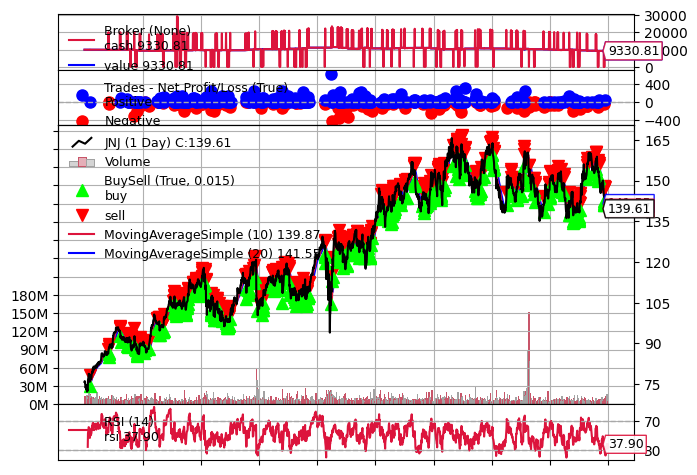

Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Exception: AttributeError: 'Lines_LineSeries_DataSeries_OHLC_OHLCDateTime_AbstractDataBase_DataBase_PandasData'
Exception: AttributeError: module 'backtrader.indicators' has no attribute 'STOCH'
Remote traceback:
Traceback 
Exception: TypeError: BollingerBands.__init__() got an unexpected keyword argument 'nbdevup'
Remote traceback:

Exception: TypeError: LineBuffer.__call__() got an unexpected keyword argument 'period'
Remote traceback:
Trace
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Return:             0.12%
Sharpe Ratio:       -34.6621423976172
Avg Annual Return:  0.01%
Max Drawdown:       0.09%


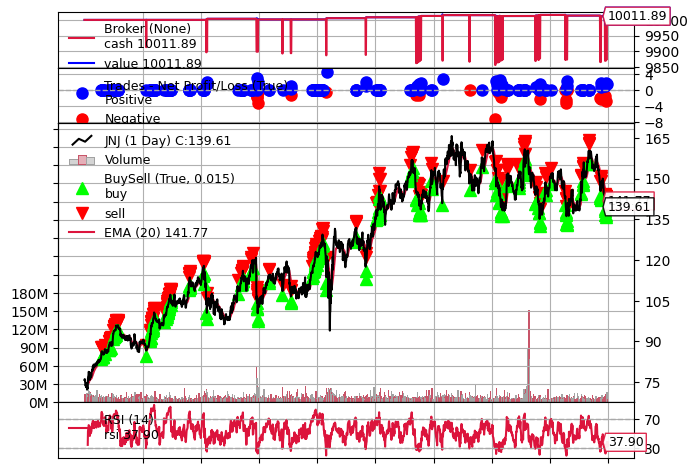

class Strategy(bt.Strategy):

    params = dict(
        rsi_period=14,
        ema_period=20,
        lowThreshold=30,
        highThreshold=70,
        leverage=0.5
    )

    def __init__(self):
        self.rsi = bt.ind.RSI(self.data.close, period=self.params.rsi_period)
        self.ema = bt.ind.EMA(self.data.close, period=self.params.ema_period)

    def next(self):
        if self.rsi < self.params.lowThreshold:
            self.close()
            self.buy()
        elif self.rsi > self.params.highThreshold:
            self.buy()
            self.sell()
        elif self.ema > self.data.close:
            self.close()
        else:
            if self.position and self.data.close > self.data.close[0] * (1 + self.params.leverage):
                self.order_target_percent(target=0.9)
            elif self.position and self.data.close < self.data.close[0] * (1 - self.params.leverage):
                self.order_target_percent(target=0.1)
            elif not self.position and se

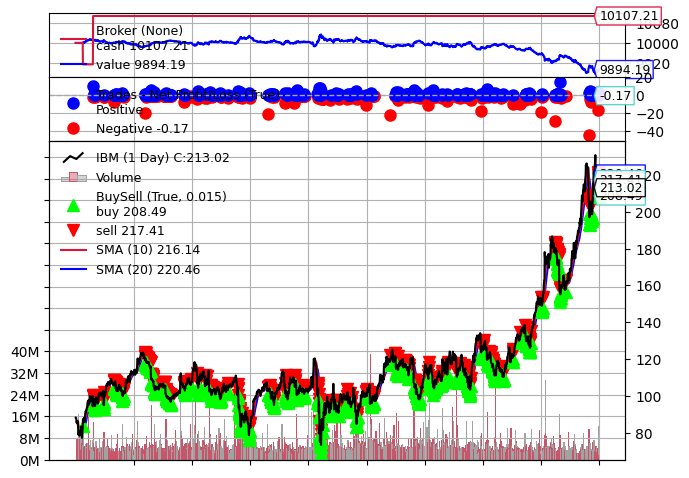

Exception: AttributeError: 'Lines_LineSeries_DataSeries_OHLC_OHLCDateTime_AbstractDataBase_DataBase_PandasData'
Return:             0.00%
Sharpe Ratio:       None
Avg Annual Return:  0.00%
Max Drawdown:       0.00%
Exception: AttributeError: module 'backtrader.indicators' has no attribute 'SmoothingMode'
Remote traceback:
Tr
Exception: AttributeError: module 'backtrader.indicators' has no attribute 'BBUpperBand'
Remote traceback:
Trac
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
CRM--2016-01-01--2024-12-31
Exception: TypeError: RelativeStrengthIndex.__init__() got an unexpected keyword argument 'periods'
Remote trac
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_IndicatorBase_Indicator_CrossOver' objec
Return:             0.89%
Sharpe Ratio:       -2.038792431239398
Avg Annual Return:  0.10%
Max Drawdown:       1.19%


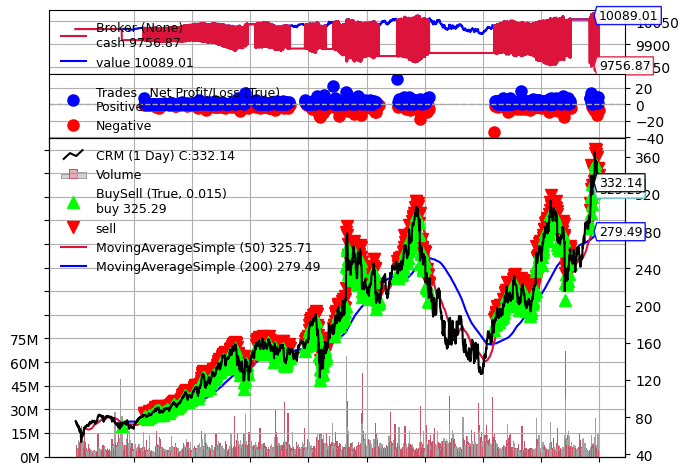

class Strategy(bt.Strategy):

    params = dict(
        period_fast=50,
        period_slow=200,
    )

    def __init__(self):
        self.fast_ma = bt.ind.MovingAverageSimple(period=self.p.period_fast)
        self.slow_ma = bt.ind.MovingAverageSimple(period=self.p.period_slow)

    def next(self):
        if not self.position:
            if self.fast_ma > self.slow_ma:
                self.buy()
        else:
            if self.slow_ma < self.fast_ma:
                self.close()
Exception: AttributeError: 'BackBroker' object has no attribute 'starting_cash'
Remote traceback:
Traceback (mo
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
NKE--2016-01-01--2024-12-31
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Return:             0.00%
Sharpe Ratio:       None
Avg Annual Return:  0.00%
Max Drawdown:       0.00%
Return:             -0.23%
Sharpe Ratio: 

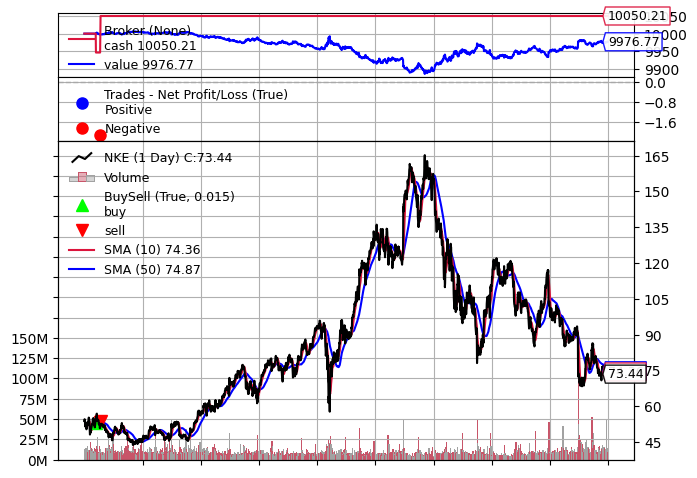

Exception: TypeError: MovingAverageSimple.__init__() got an unexpected keyword argument 'max_lookahead'
Remote 
Exception: AttributeError: module 'backtrader.signal' has no attribute 'SMA'
Remote traceback:
Traceback (most 
Return:             0.36%
Sharpe Ratio:       -8.76629252470978
Avg Annual Return:  0.04%
Max Drawdown:       0.25%


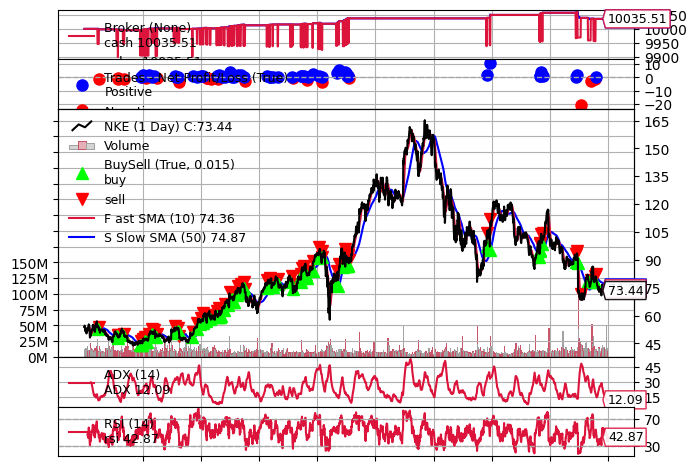

class Strategy(bt.Strategy):
    params = dict(
        buy_crit=15,
        sell_crit=25,
        period=14,
        use_fast_sma=True,
        initial_position=1000,
        cash_division=0.1
    )

    def __init__(self):
        selfadx = bt.indicators.ADX(self.data, period=self.p.period)
        self.sma_short = bt.indicators.SMA(self.data, period=10, plotname='F ast SMA')
        self.sma_long = bt.indicators.SMA(self.data, period=50, plotname='S Slow SMA')
        self.rsi = bt.indicators.RSI(self.data.close)

    def next(self):
        if self.data.close > self.sma_long and self.data.close < self.sma_short:
            if self.position.size == 0:
                amount = self.p.initial_position * self.p.cash_division
                self.order = self.buy(exectype=bt.Order.Limit, size=int(amount / self.data.close), price=self.data.close)
        elif self.rsi < self.p.buy_crit:
            if self.position.size == 0:
                amount = self.p.initial_position * self.p.cas

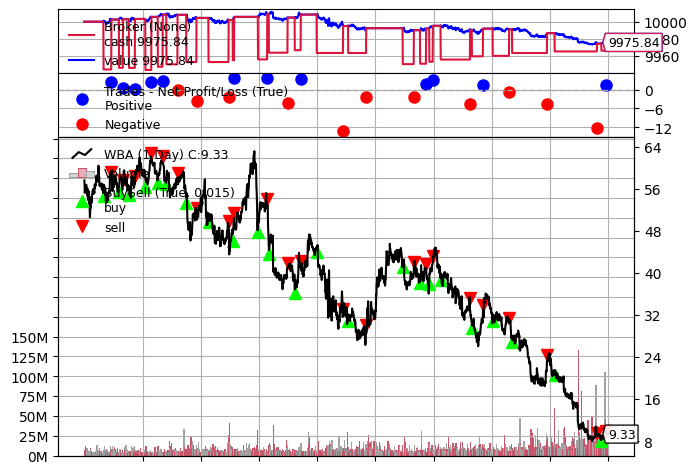

Exception: TypeError: 'AutoInfoClass_LineRoot_LineMultiple_LineSeries_LineIterator_DataAccessor_StrategyBase_St
Exception: AttributeError: module 'backtrader' has no attribute 'Position毯'
Remote traceback:
Traceback (most r
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Return:             0.00%
Sharpe Ratio:       None
Avg Annual Return:  0.00%
Max Drawdown:       0.00%
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Exception: TypeError: RelativeStrengthIndex.__init__() got an unexpected keyword argument 'price'
Remote traceb
NKE--2016-01-01--2024-12-31
Return:             -4.22%
Sharpe Ratio:       -1.0783294871623925
Avg Annual Return:  -0.47%
Max Drawdown:       8.17%


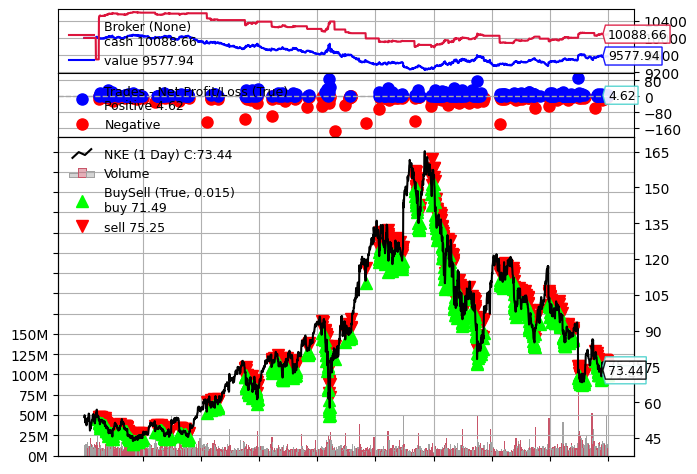

Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h
Exception: NameError: name 'params' is not defined
Remote traceback:
Traceback (most recent call last):
  File 
Exception: TypeError: unsupported operand type(s) for %: 'ExponentialMovingAverage' and 'SimpleMovingAverage'
R
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_IndicatorBase_Indicator_MovingAverageBas
Exception: AttributeError: module 'backtrader.indicators' has no attribute 'BB'
Remote traceback:
Traceback (mo
Return:             0.00%
Sharpe Ratio:       None
Avg Annual Return:  0.00%
Max Drawdown:       0.00%
Exception: AttributeError: 'Lines_LineSeries_LineIterator_DataAccessor_StrategyBase_Strategy_Strategy' object h


In [ ]:
model.train(
    steps=100,
    reward_functions = [RewardFunctions.strategy_succeeds],
    dataset = data.get_dataset(),
)